In [58]:
%load_ext autoreload
%autoreload 2

In [59]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, \
    jablje_readily_evaporable_water, jablje_maize_params, jablje_optimal_management, jablje_initial_cond, \
    jablje_groundwater
from aquacrop_slovenia.diagnostics import nse, kge, mkge

In [60]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing_daily"
LOCATION = "jablje"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [61]:
year = 2003
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
]
#for year in range(1993, 2024) if year not in [2017]]

In [62]:
jablje_temperatures, jablje_eto, jablje_rain = get_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [63]:
historical_co2 = get_co2_for_aquacrop("historical")

In [64]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [65]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [66]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [67]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=jablje_weather,
    #ground_water=jablje_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [68]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

In [69]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,2003,667.6,768.7,1369.8,374.22,0.0,574.5,...,46.0,7.803,10.268,2.31,0.0,0.0,10,10,2003,PROJECT.PRM


In [70]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,2003,-9,0,767.8,9.9,0.0,0.0,9.2,...,None,None,None,None,None,None,None,None,None,None
1,2,1,2003,-9,0,767.4,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,2003,-9,0,773.0,6.2,0.0,0.0,5.8,...,None,None,None,None,None,None,None,None,None,None
3,4,1,2003,-9,0,772.5,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,2003,-9,0,773.2,0.9,0.0,0.0,0.9,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,2003,-9,0,779.1,9.3,0.0,0.0,8.1,...,None,None,None,None,None,None,None,None,None,None
279,7,10,2003,-9,0,778.6,0.5,0.0,0.0,0.5,...,None,None,None,None,None,None,None,None,None,None
280,8,10,2003,-9,0,780.0,3.9,0.0,0.0,3.8,...,None,None,None,None,None,None,None,None,None,None
281,9,10,2003,-9,0,777.0,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

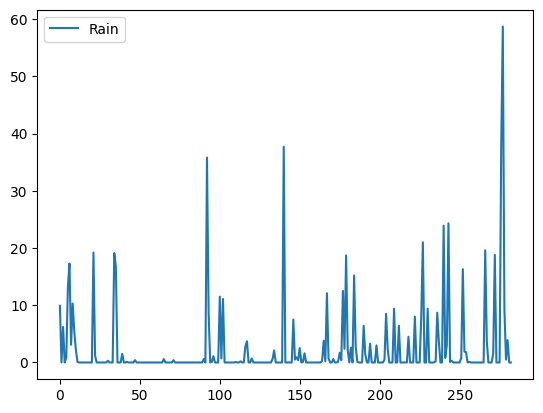

In [71]:
results["day"].plot(y="Rain")

<Axes: >

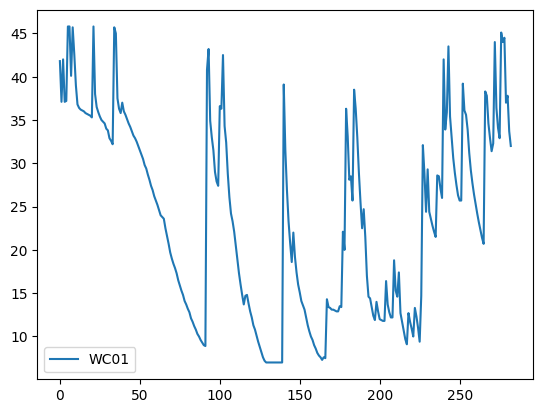

In [72]:
results["day"].plot(y="WC01")

<Axes: >

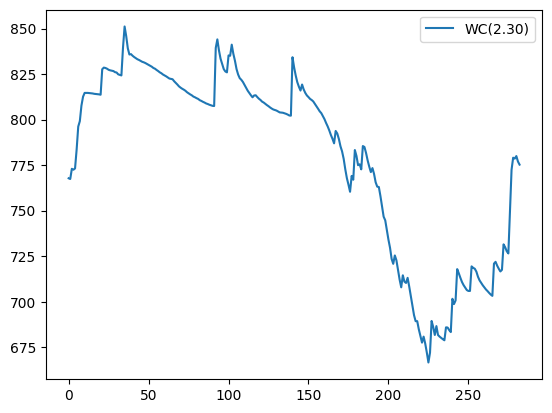

In [73]:
results["day"].plot(y="WC(2.30)")

<Axes: >

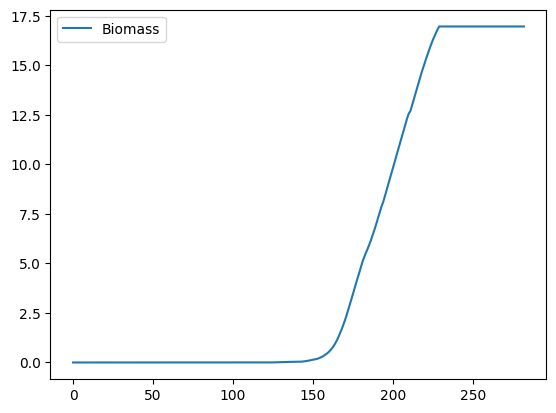

In [74]:
results["day"].plot(y="Biomass")

<Axes: >

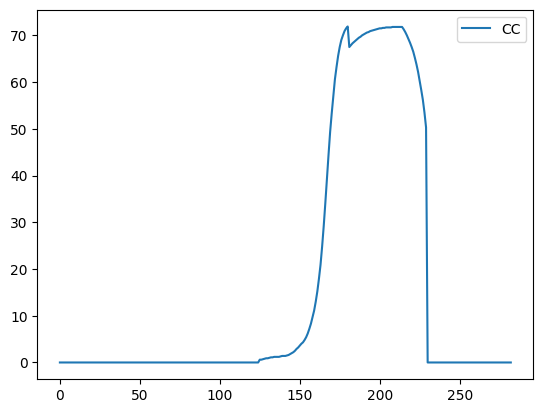

In [75]:
results["day"].plot(y="CC")

<Axes: >

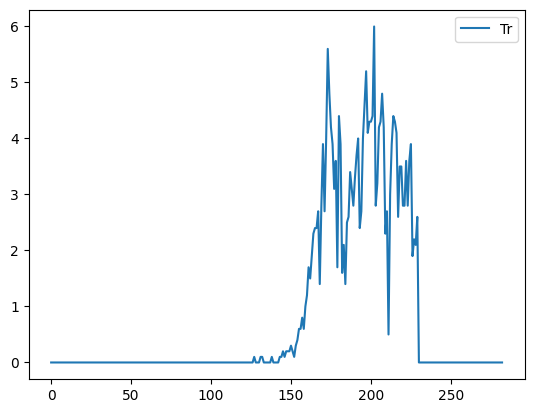

In [76]:
results["day"].plot(y="Tr")

<Axes: >

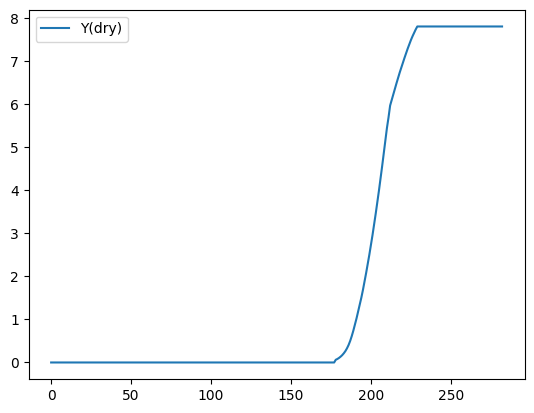

In [77]:
results["day"].plot(y="Y(dry)")

In [78]:
import contextlib
import copy
import io
import queue
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.cm as cm
import numpy as np

In [79]:
gdd_sweep_params = {
    "gdd_emergence":        [15, 22, 29, 36, 44],              # default: 29
    "gdd_max_rooting":      [900, 990, 1084, 1175, 1265],      # default: 1084
    "gdd_senescence":       [880, 975, 1072, 1170, 1265],      # default: 1072
    "gdd_maturity":         [1100, 1210, 1320, 1430, 1550],    # default: 1320
    "gdd_cycle_length":     [1500, 1600, 1700, 1800, 1900],    # default: 1700
    "gdd_flowering":        [400, 455, 508, 560, 615],         # default: 508
    "gdd_flowering_length": [100, 125, 150, 175, 200],         # default: 150
    "gdd_hi_start":         [400, 455, 512, 570, 625],         # default: 512
}

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

import os
MAX_WORKERS = os.cpu_count()
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"daily_gdd_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

gdd_dir_queue = queue.Queue()
for d in worker_dirs:
    gdd_dir_queue.put(d)


def run_gdd_param(param_name, value):
    working_dir = gdd_dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        params[param_name] = int(round(value)) if param_name in INTEGER_PARAMS else float(value)
        crop = Crop(name=f"{LOCATION} maize", description=f"{param_name}={value}", params=params)
        sim = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=jablje_soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=jablje_weather,
            ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=True,
            need_seasonal_output=False,
            need_harvest_output=False,
            need_evaluation_output=False,
        )
        with contextlib.redirect_stdout(io.StringIO()):
            res = sim.run()
        daily = res["day"]
        return param_name, value, daily[daily["DAP"] >= 0].copy()
    finally:
        gdd_dir_queue.put(working_dir)


gdd_daily_results = {name: {} for name in gdd_sweep_params}

tasks = [(name, val) for name, values in gdd_sweep_params.items() for val in values]
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_gdd_param, name, val) for name, val in tasks]
    for future in as_completed(futures):
        param_name, value, daily = future.result()
        gdd_daily_results[param_name][value] = daily

print("Done.")

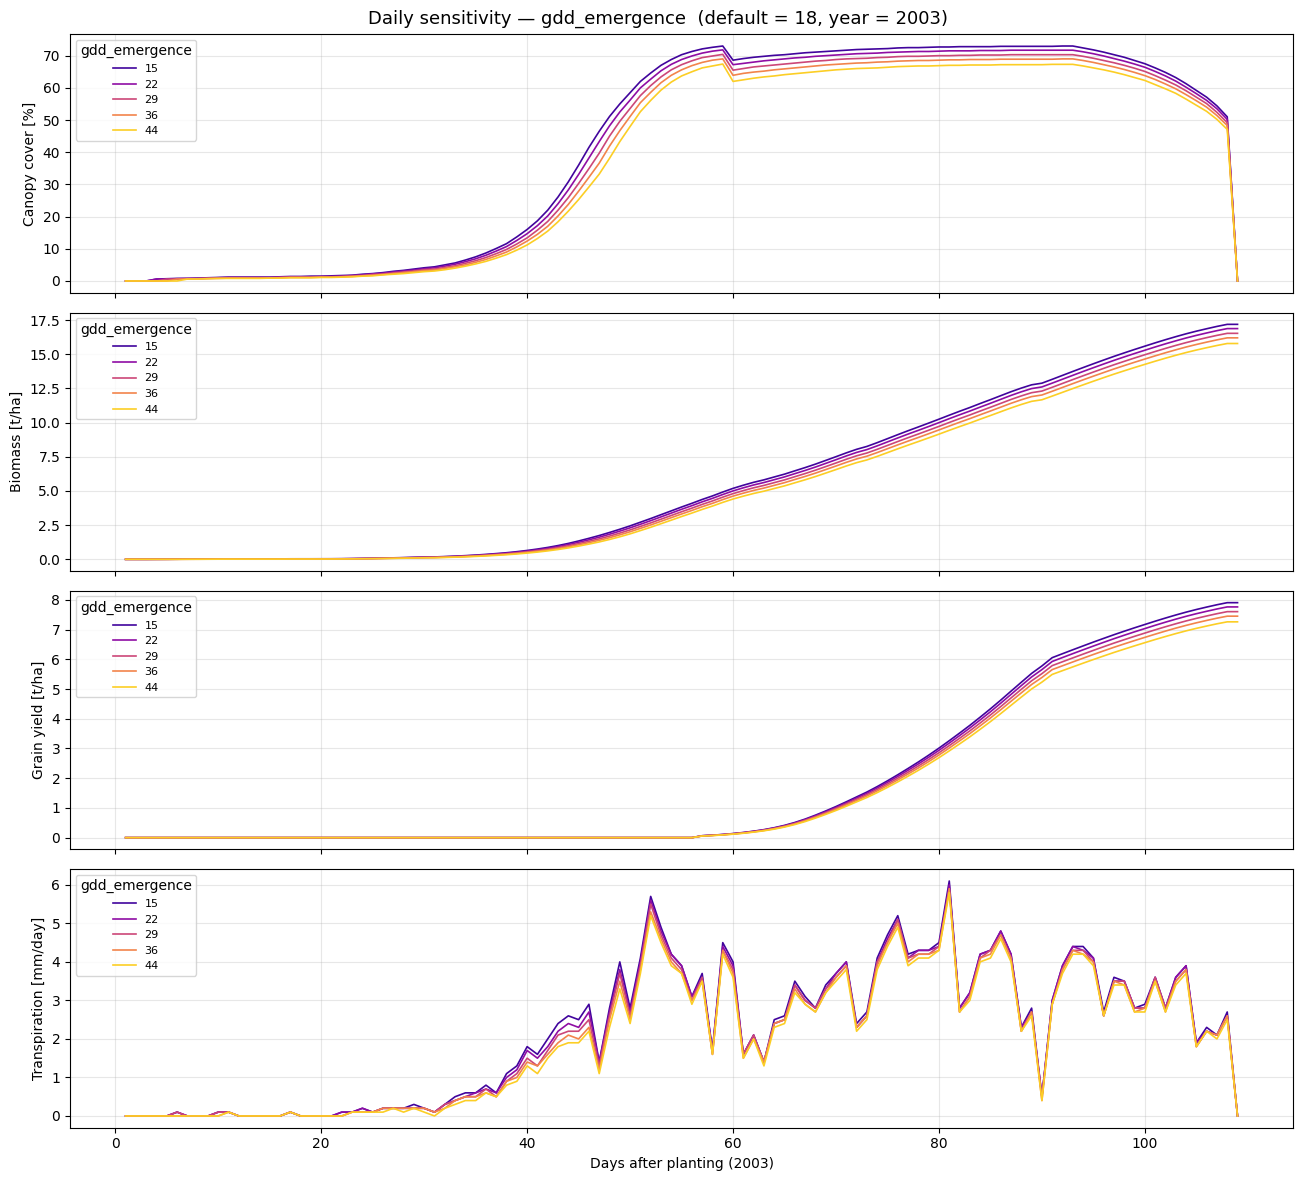

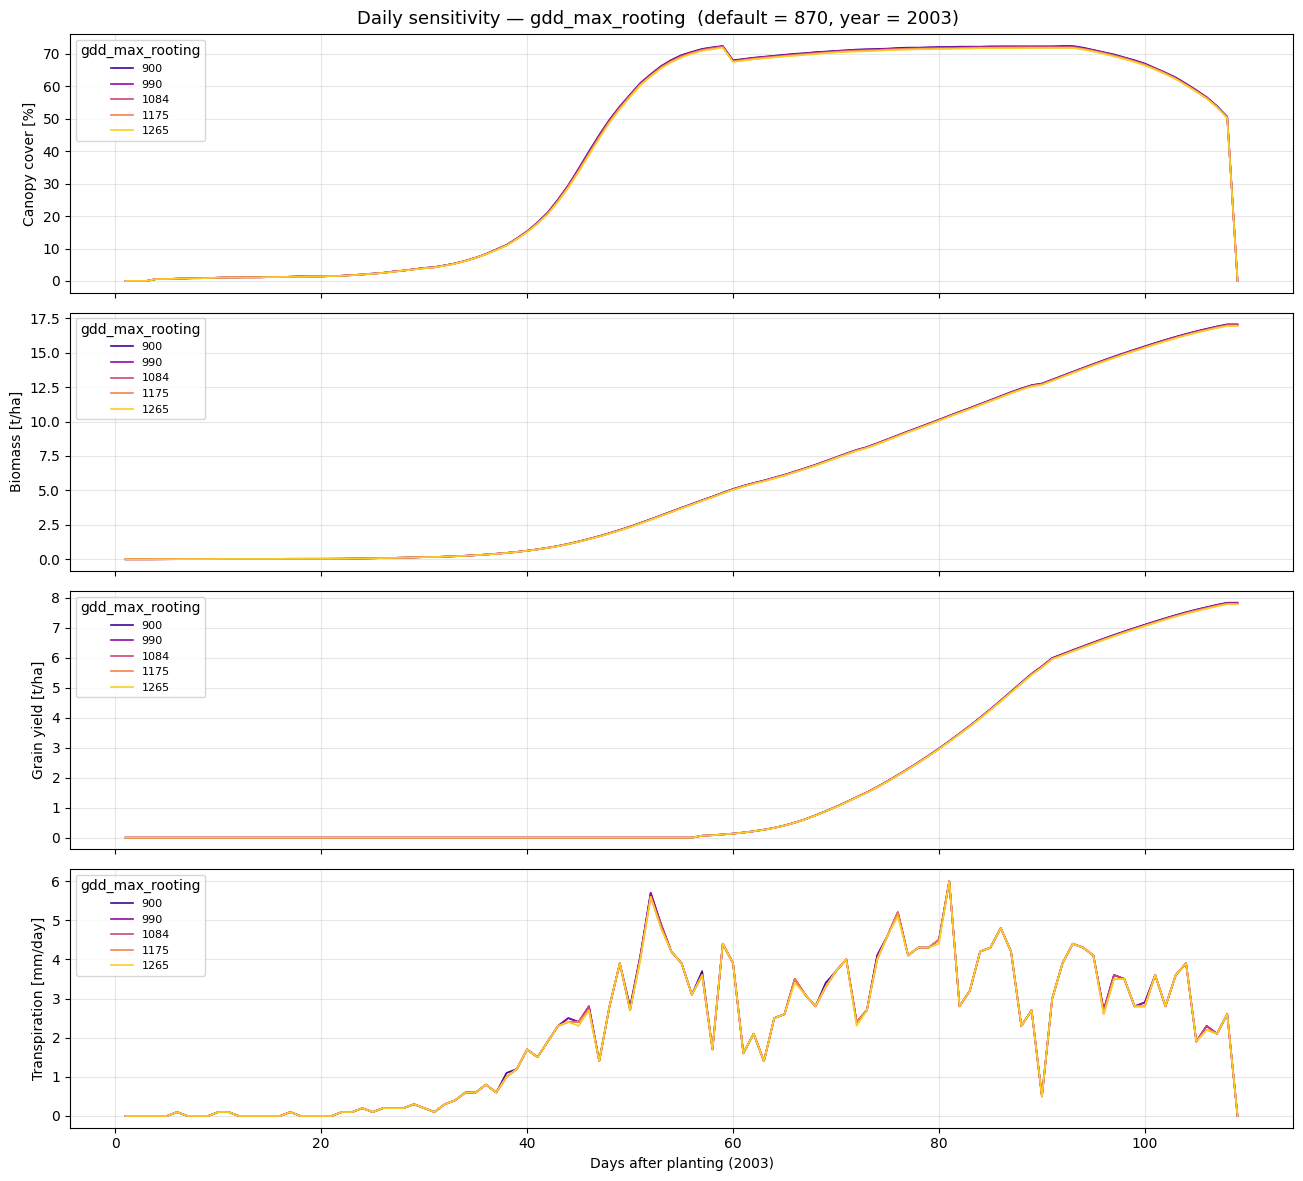

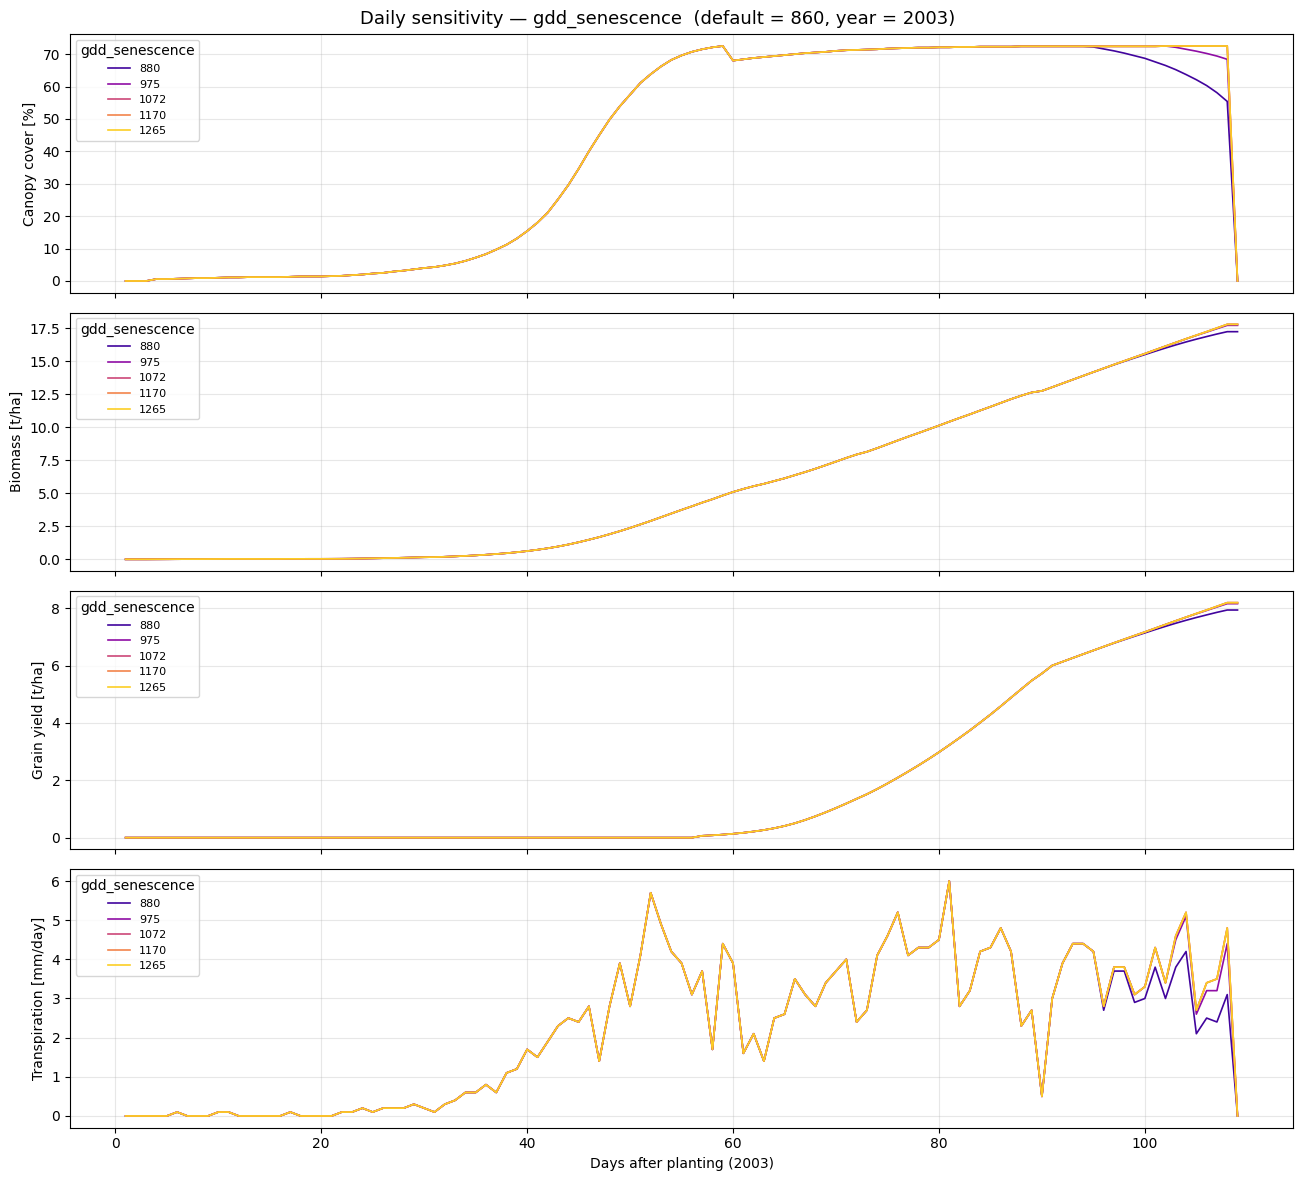

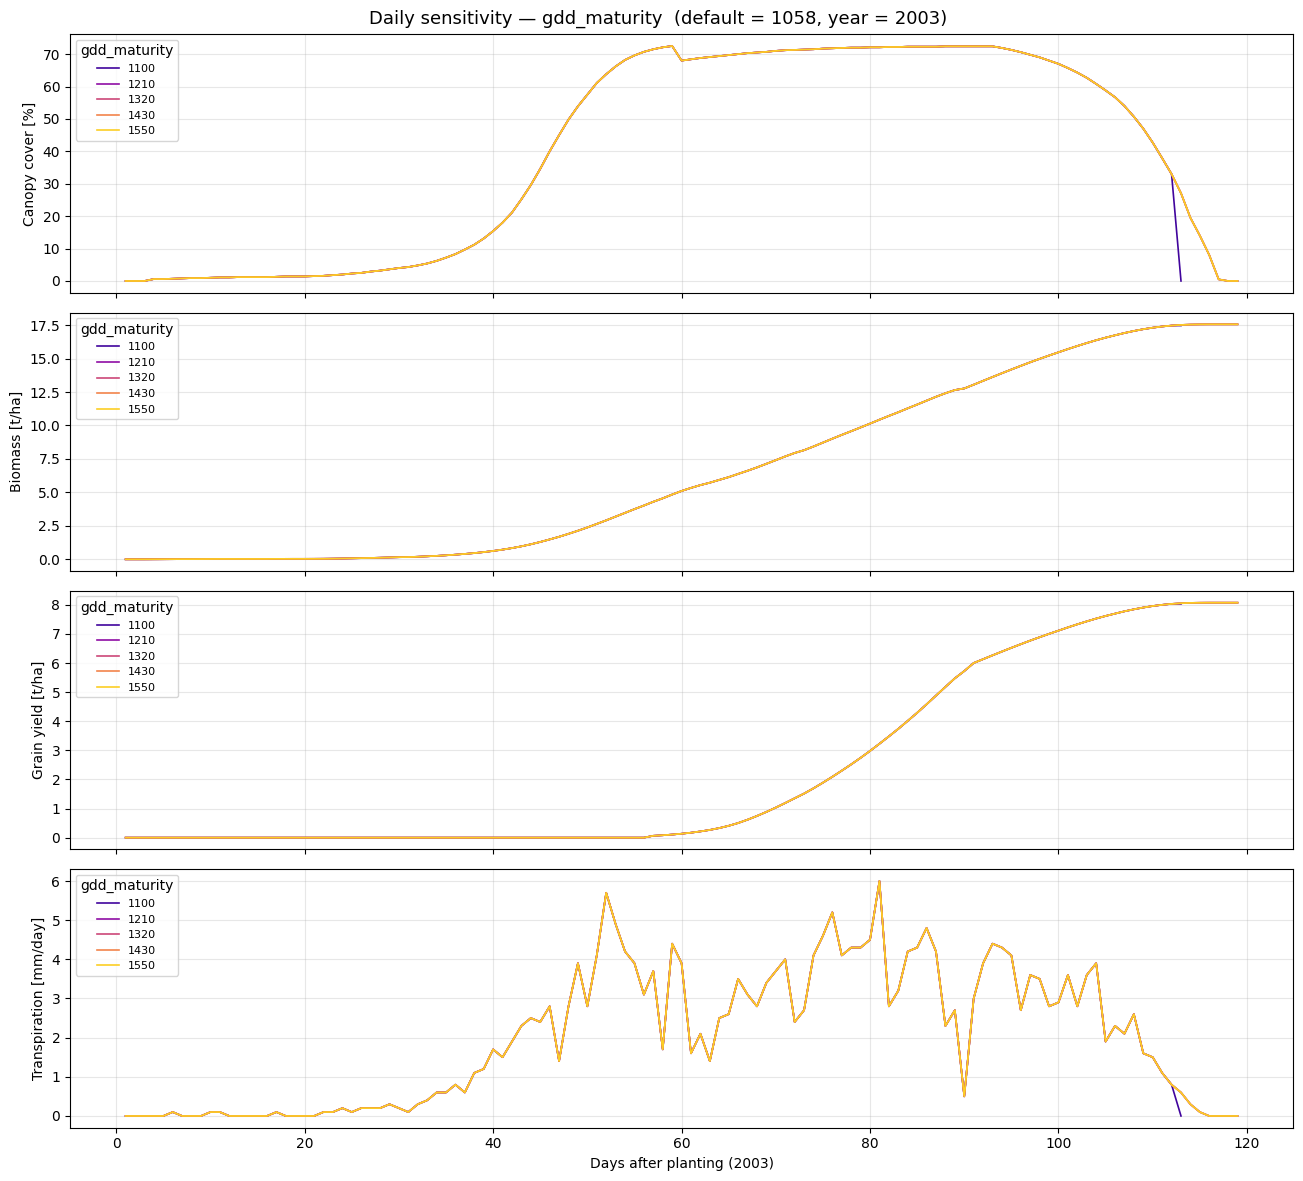

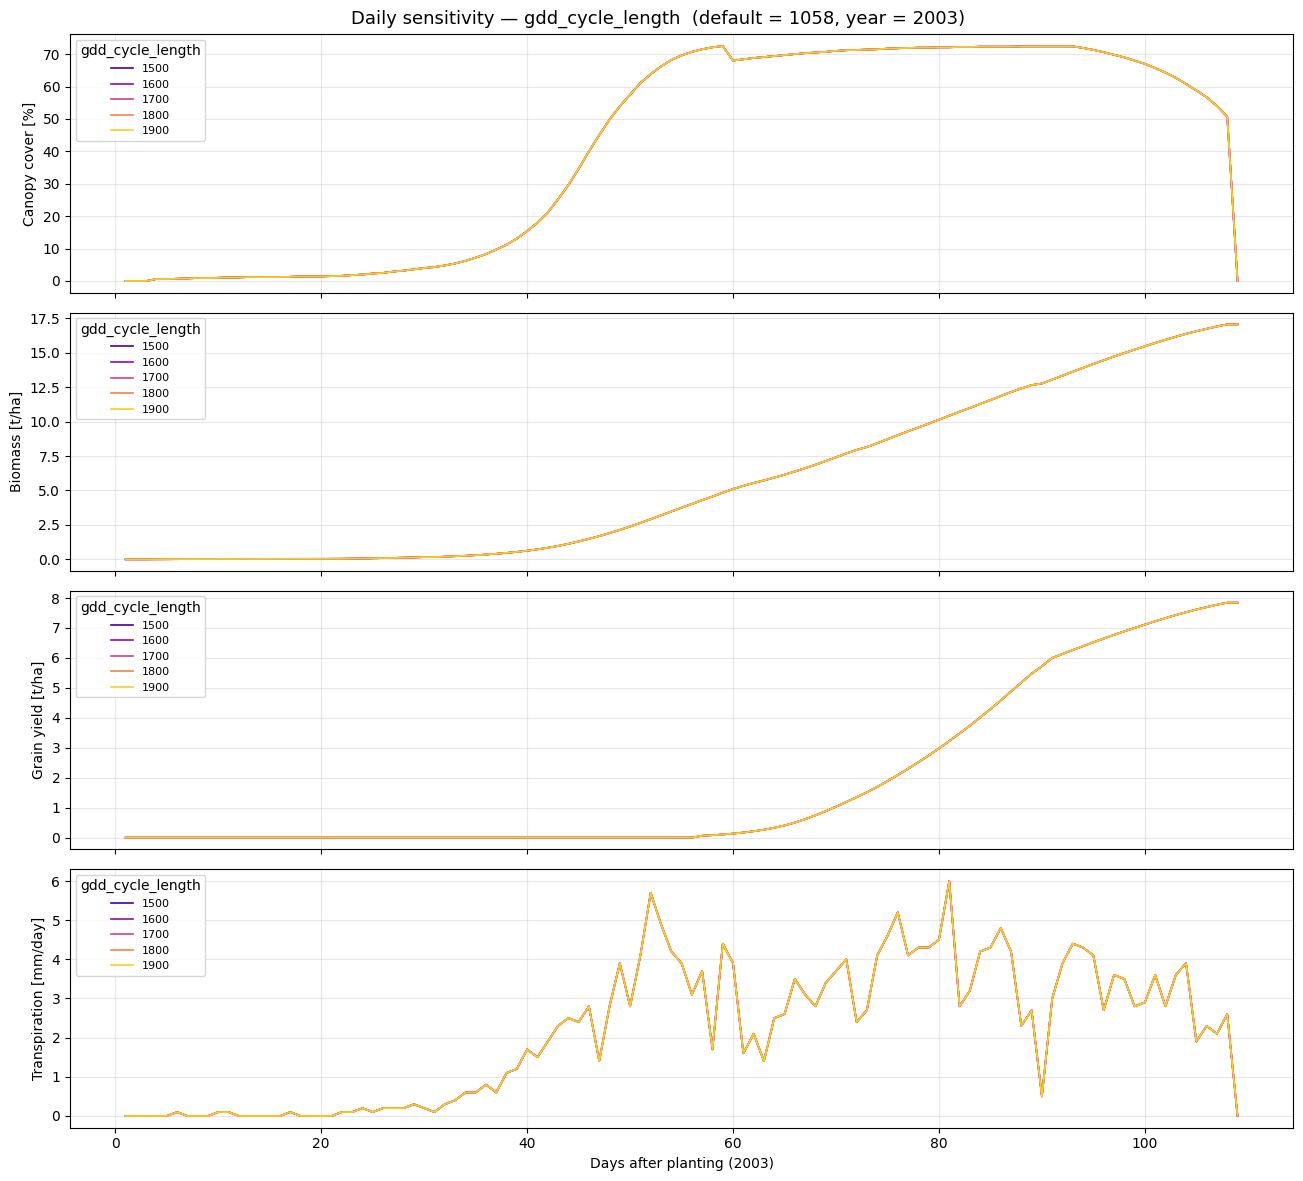

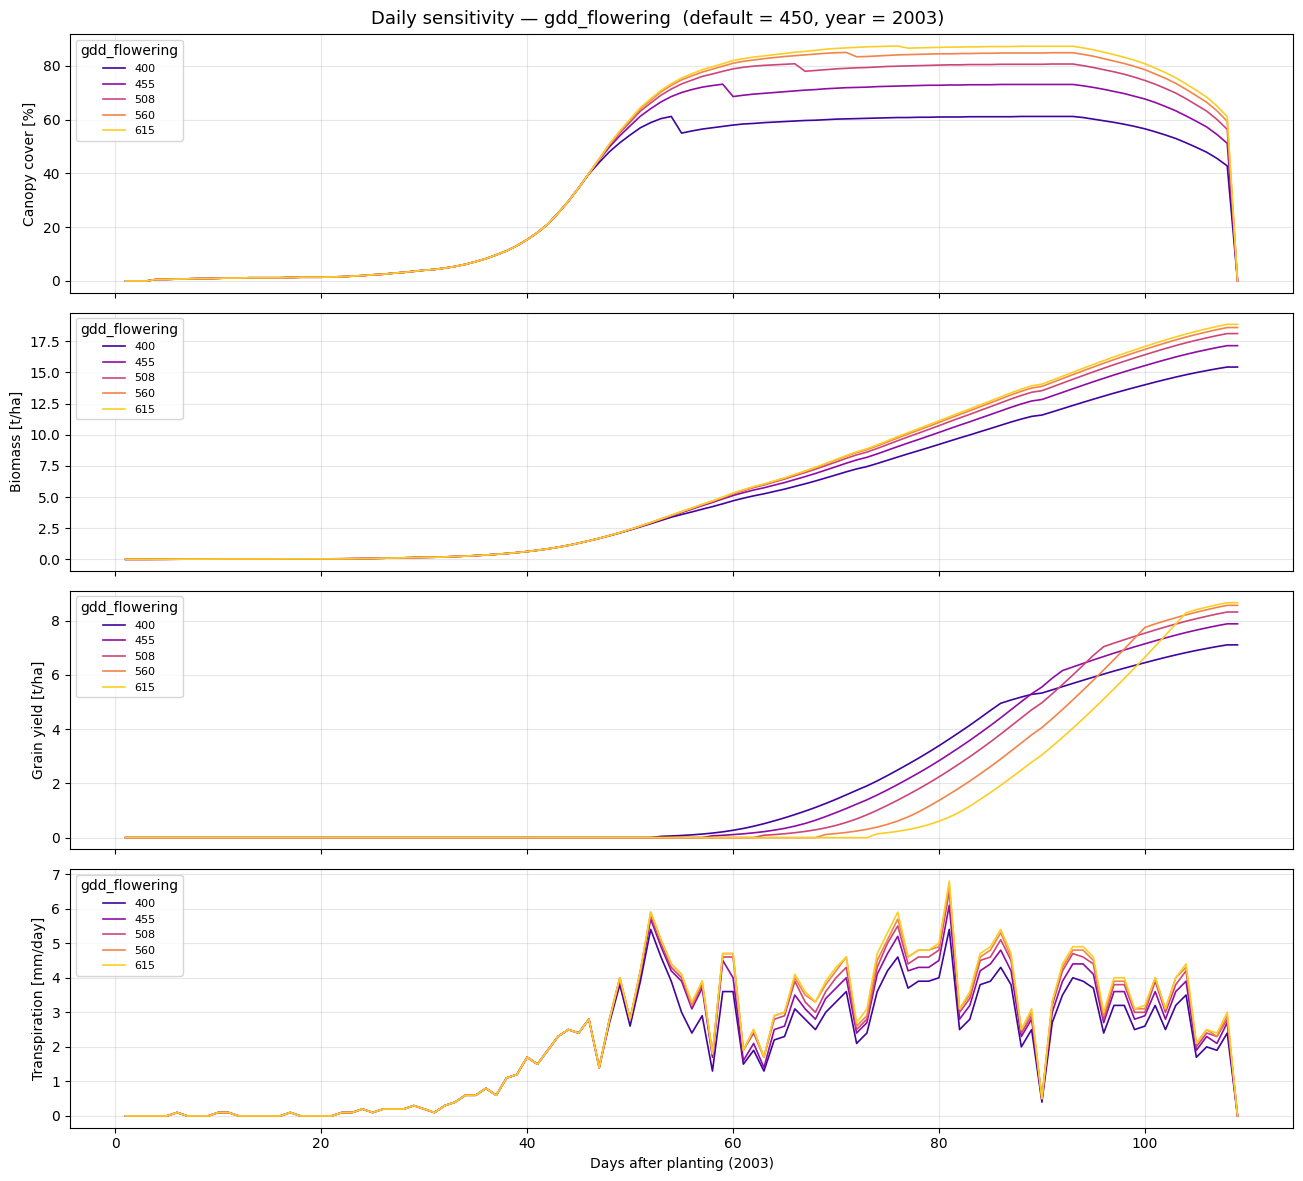

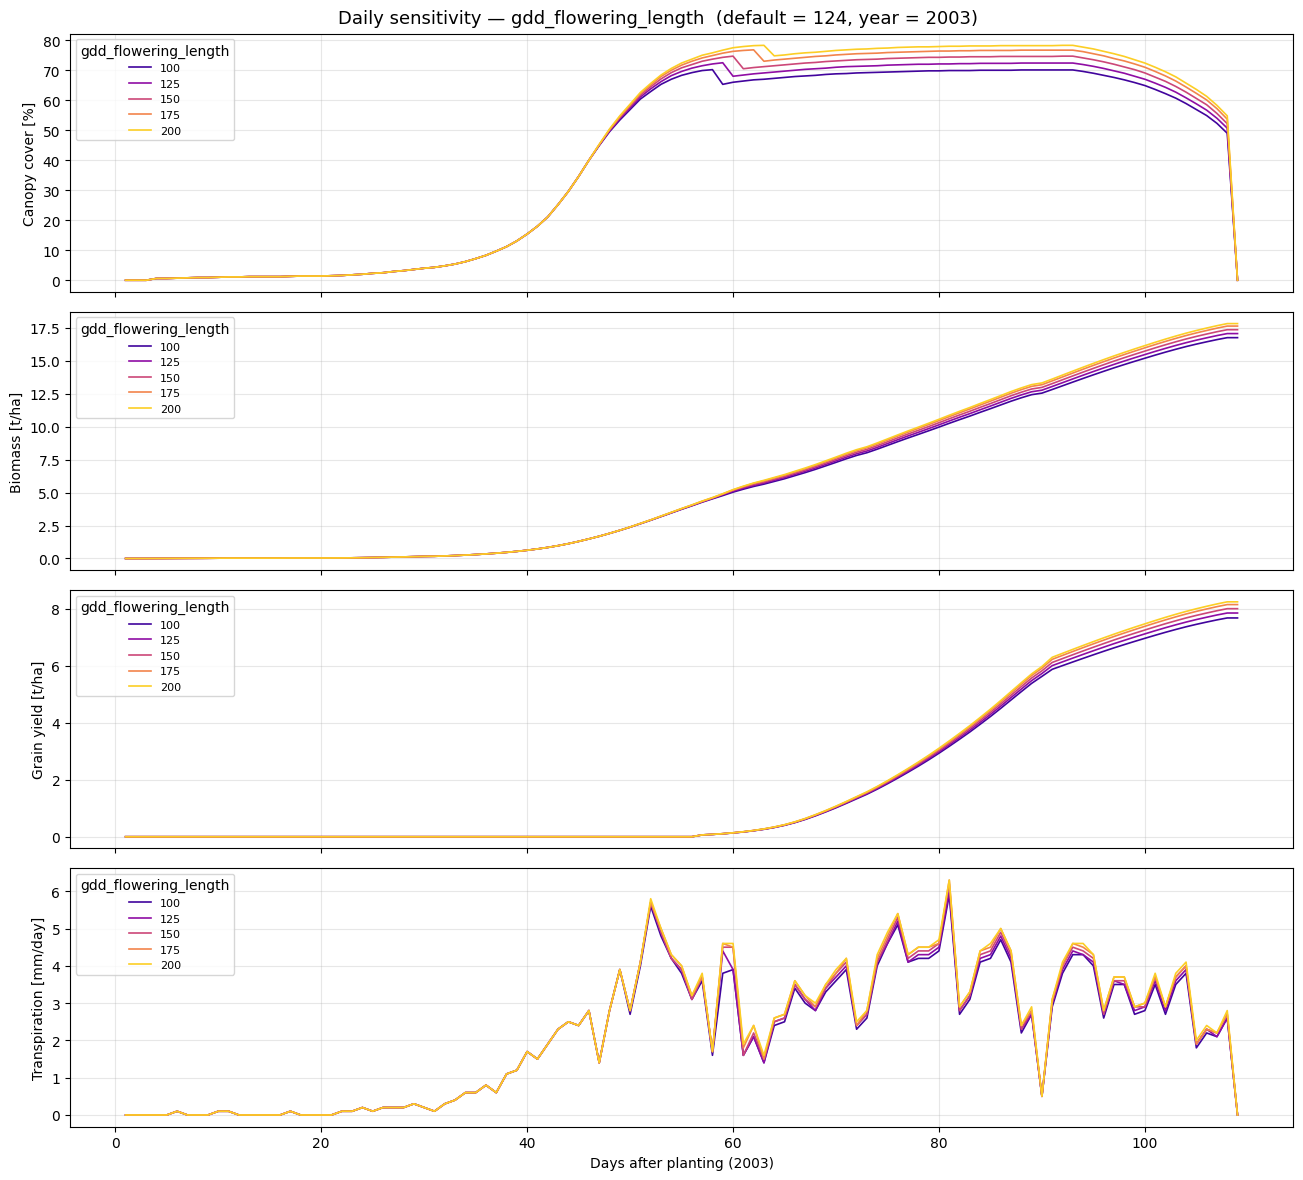

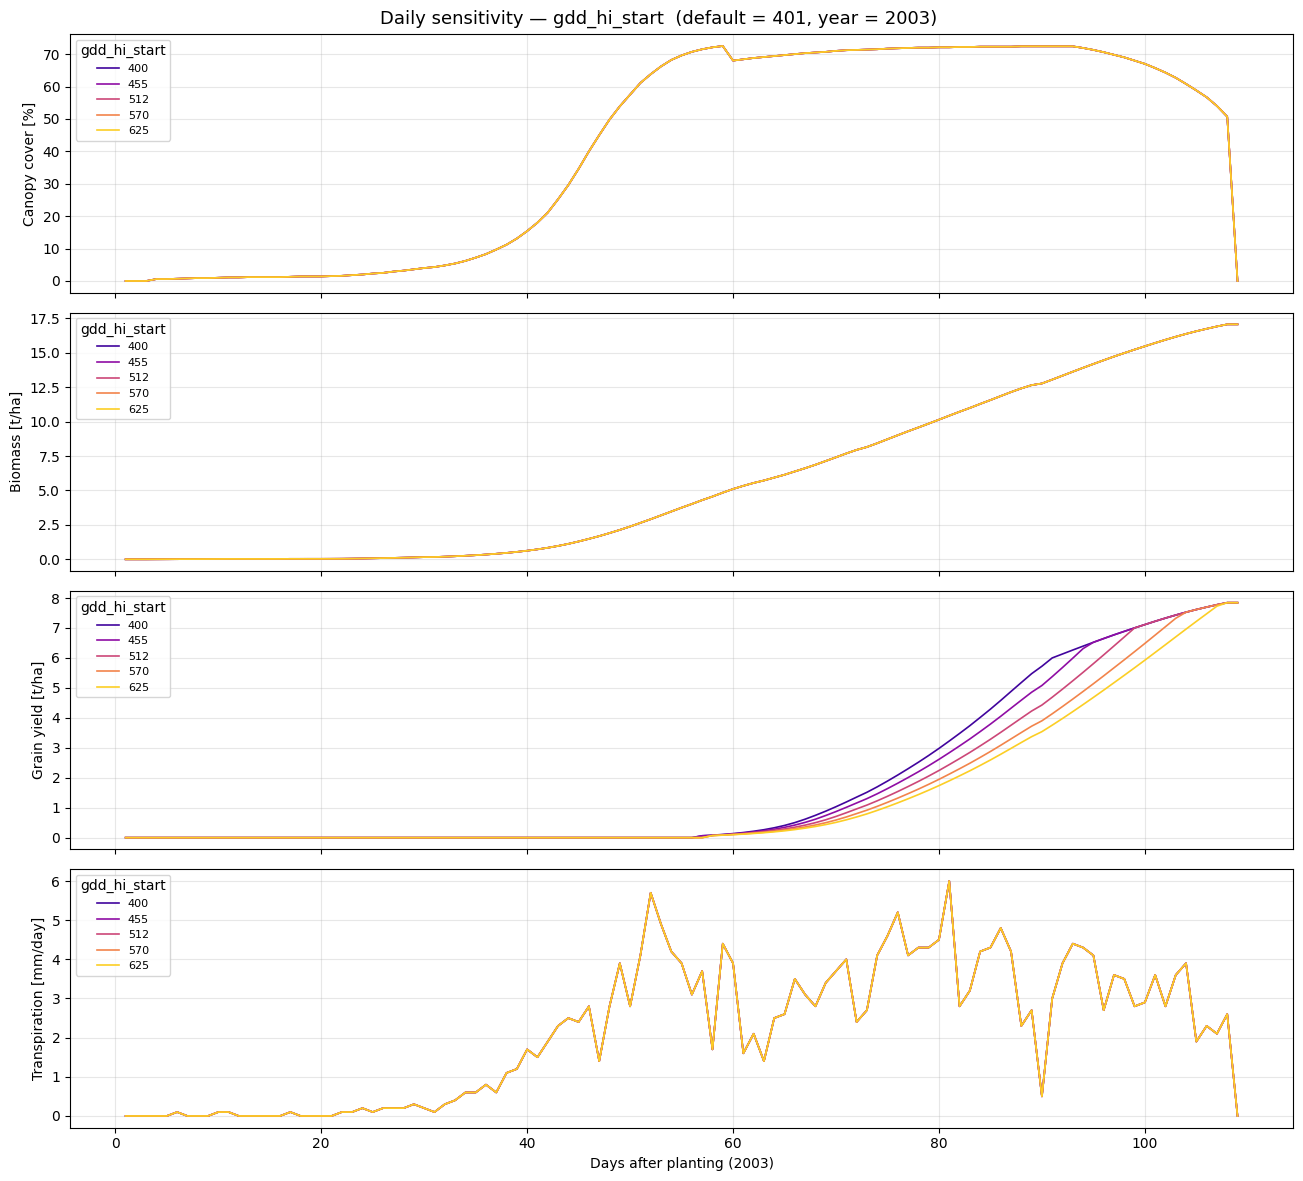

In [80]:
from matplotlib import pyplot as plt

daily_panels = [
    ("CC",      "Canopy cover [%]"),
    ("Biomass", "Biomass [t/ha]"),
    ("Y(dry)",  "Grain yield [t/ha]"),
    ("Tr",      "Transpiration [mm/day]"),
]

for param_name, results_by_value in gdd_daily_results.items():
    values = sorted(results_by_value.keys())
    default_val = jablje_maize_params[param_name]
    colors = cm.plasma(np.linspace(0.1, 0.9, len(values)))

    fig, axes = plt.subplots(len(daily_panels), 1, figsize=(13, 3 * len(daily_panels)), sharex=True)
    fig.suptitle(
        f"Daily sensitivity — {param_name}  (default = {default_val}, year = {year})",
        fontsize=13,
    )

    for ax, (col, ylabel) in zip(axes, daily_panels):
        for val, color in zip(values, colors):
            daily = results_by_value[val]
            lw = 2.5 if val == default_val else 1.2
            ls = "--" if val == default_val else "-"
            ax.plot(
                daily["DAP"].values,
                daily[col].values,
                color=color,
                linewidth=lw,
                linestyle=ls,
                label=f"{val:.4g}" + (" (default)" if val == default_val else ""),
            )
        ax.set_ylabel(ylabel)
        ax.legend(title=param_name, fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(f"Days after planting ({year})")
    plt.tight_layout()
    plt.show()